In [1]:
print("Hello! Python is working.")

Hello! Python is working.


In [2]:
import pandas as pd

print("Pandas version:", pd.__version__)
print("Pandas is working!")

Pandas version: 3.0.5
Pandas is working!


In [3]:
file_path = "../data/training.1600000.processed.noemoticon.csv"

sample_data = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    nrows=5
)

sample_data

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
label_counts = {}

for chunk in pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    usecols=[0],
    chunksize=100000
):
    counts = chunk[0].value_counts()

    for label, count in counts.items():
        label_counts[label] = label_counts.get(label, 0) + count

print("Sentiment labels:", label_counts)

Sentiment labels: {0: 800000, 4: 800000}


# Phase 1: Dataset Preparation and Verification

## Project Objective
Build a machine learning-based sentiment analysis system for text classification.

## Datasets
1. Sentiment140 — Twitter sentiment dataset
2. IMDb Large Movie Review Dataset — Movie review sentiment dataset

## Sentiment140 Verification
- Total training records: 1,600,000
- Negative tweets (0): 800,000
- Positive tweets (4): 800,000
- Neutral tweets (2): 0
- Dataset is balanced.

In [1]:
from pathlib import Path

imdb_path = Path("../data/aclImdb")

train_pos = len(list((imdb_path / "train" / "pos").glob("*.txt")))
train_neg = len(list((imdb_path / "train" / "neg").glob("*.txt")))

test_pos = len(list((imdb_path / "test" / "pos").glob("*.txt")))
test_neg = len(list((imdb_path / "test" / "neg").glob("*.txt")))

print("IMDb Dataset Verification")
print("-------------------------")
print("Training positive reviews:", train_pos)
print("Training negative reviews:", train_neg)
print("Training total:", train_pos + train_neg)
print()
print("Testing positive reviews:", test_pos)
print("Testing negative reviews:", test_neg)
print("Testing total:", test_pos + test_neg)

IMDb Dataset Verification
-------------------------
Training positive reviews: 12500
Training negative reviews: 12500
Training total: 25000

Testing positive reviews: 12500
Testing negative reviews: 12500
Testing total: 25000


## IMDb Dataset Verification

- Training reviews: 25,000
  - Positive: 12,500
  - Negative: 12,500
- Testing reviews: 25,000
  - Positive: 12,500
  - Negative: 12,500
- Total labeled reviews: 50,000
- Dataset is balanced.
- The labeled dataset contains only positive and negative sentiment classes.
- No neutral sentiment class is present.

# Phase 2: Exploratory Data Analysis

## Objectives

- Load and inspect the raw datasets.
- Understand dataset structure and data types.
- Check for missing and duplicate records.
- Analyze sentiment class distribution.
- Analyze tweet and review text characteristics.
- Examine representative positive and negative examples.
- Visualize important characteristics of the datasets.

In [2]:
sentiment_columns = [
    "sentiment",
    "tweet_id",
    "date",
    "query",
    "user",
    "text"
]

sentiment_sample = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    names=sentiment_columns,
    nrows=200000
)

print("Sentiment140 sample shape:", sentiment_sample.shape)
sentiment_sample.head()

NameError: name 'pd' is not defined

In [3]:
import pandas as pd

In [4]:
sentiment_columns = [
    "sentiment",
    "tweet_id",
    "date",
    "query",
    "user",
    "text"
]

sentiment_sample = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    names=sentiment_columns,
    nrows=200000
)

print("Sentiment140 sample shape:", sentiment_sample.shape)
sentiment_sample.head()

NameError: name 'file_path' is not defined

In [5]:
file_path = r"C:\Users\Abinaya RS\Sentiment-Analysis\data\training.1600000.processed.noemoticon"

In [8]:
sentiment_sample = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    names=sentiment_columns,
    nrows=200000
)

print("Sentiment140 sample shape:", sentiment_sample.shape)
sentiment_sample.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Abinaya RS\\Sentiment-Analysis\\data\\training.1600000.processed.noemoticon'

In [10]:
file_path = r"C:\Users\Abinaya RS\Sentiment-Analysis\data\training.1600000.processed.noemoticon.csv"

In [11]:
sentiment_sample = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    names=sentiment_columns,
    nrows=200000
)

print("Sentiment140 sample shape:", sentiment_sample.shape)
sentiment_sample.head()

Sentiment140 sample shape: (200000, 6)


,sentiment,tweet_id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [12]:
# Check for missing values

print("Missing values:")
print(sentiment_sample.isnull().sum())

Missing values:
sentiment    0
tweet_id     0
date         0
query        0
user         0
text         0
dtype: int64


In [13]:
# Check for duplicate tweets

duplicate_count = sentiment_sample["text"].duplicated().sum()

print("Duplicate tweets:", duplicate_count)

Duplicate tweets: 1839


In [14]:
# Remove duplicate tweets

sentiment_sample = sentiment_sample.drop_duplicates(
    subset="text"
).reset_index(drop=True)

print("Shape after removing duplicates:", sentiment_sample.shape)

Shape after removing duplicates: (198161, 6)


In [15]:
# Convert sentiment labels to readable names

sentiment_sample["sentiment_label"] = sentiment_sample["sentiment"].map({
    0: "negative",
    4: "positive"
})

print(sentiment_sample["sentiment_label"].value_counts())

sentiment_label
negative    198161
Name: count, dtype: int64


In [16]:
# Load a balanced sample from Sentiment140

negative_sample = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    names=sentiment_columns,
    nrows=100000
)

positive_sample = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    names=sentiment_columns,
    skiprows=800000,
    nrows=100000
)

sentiment_sample = pd.concat(
    [negative_sample, positive_sample],
    ignore_index=True
)

print("Balanced dataset shape:", sentiment_sample.shape)
print("\nSentiment distribution:")
print(sentiment_sample["sentiment"].value_counts())

Balanced dataset shape: (200000, 6)

Sentiment distribution:
sentiment
0    100000
4    100000
Name: count, dtype: int64


In [17]:
# Remove duplicate tweets

duplicate_count = sentiment_sample["text"].duplicated().sum()

print("Duplicate tweets found:", duplicate_count)

sentiment_sample = sentiment_sample.drop_duplicates(
    subset="text"
).reset_index(drop=True)

print("Shape after removing duplicates:", sentiment_sample.shape)

Duplicate tweets found: 1578
Shape after removing duplicates: (198422, 6)


In [18]:
# Convert sentiment labels to readable names

sentiment_sample["sentiment_label"] = sentiment_sample["sentiment"].map({
    0: "negative",
    4: "positive"
})

print("Sentiment distribution:")
print(sentiment_sample["sentiment_label"].value_counts())

Sentiment distribution:
sentiment_label
positive    99240
negative    99182
Name: count, dtype: int64


In [20]:
import re

def clean_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove @mentions
    text = re.sub(r"@\w+", "", text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-z\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

print("Text cleaning function created successfully!")

Text cleaning function created successfully!


In [21]:
# Apply text cleaning

sentiment_sample["clean_text"] = sentiment_sample["text"].apply(clean_text)

print("Text cleaning completed!")

Text cleaning completed!


In [22]:
# Compare original and cleaned tweets

print("Original:")
print(sentiment_sample["text"].iloc[0])

print("\nCleaned:")
print(sentiment_sample["clean_text"].iloc[0])

Original:
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Cleaned:
a thats a bummer you shoulda got david carr of third day to do it d


In [23]:
# Check for empty tweets after cleaning

empty_count = (sentiment_sample["clean_text"] == "").sum()

print("Empty tweets after cleaning:", empty_count)

Empty tweets after cleaning: 379


In [24]:
# Remove tweets that became empty after cleaning

sentiment_sample = sentiment_sample[
    sentiment_sample["clean_text"] != ""
].reset_index(drop=True)

print("Shape after removing empty tweets:", sentiment_sample.shape)

Shape after removing empty tweets: (198043, 8)


In [25]:
# Final sentiment distribution check

print("Final dataset shape:", sentiment_sample.shape)

print("\nFinal sentiment distribution:")
print(sentiment_sample["sentiment_label"].value_counts())

Final dataset shape: (198043, 8)

Final sentiment distribution:
sentiment_label
positive    99041
negative    99002
Name: count, dtype: int64


In [26]:
# Check cleaned tweet lengths

sentiment_sample["text_length"] = sentiment_sample["clean_text"].str.len()

print("Minimum text length:", sentiment_sample["text_length"].min())
print("Maximum text length:", sentiment_sample["text_length"].max())
print("Average text length:", round(sentiment_sample["text_length"].mean(), 2))

Minimum text length: 1
Maximum text length: 158
Average text length: 62.44


# Phase 2: Data Exploration and Cleaning

## Objective
Prepare the Sentiment140 dataset for machine learning by checking data quality, removing duplicates, converting sentiment labels, and cleaning tweet text.

## Data Cleaning Steps

1. Checked for missing values.
   - Result: No missing values found.

2. Checked for duplicate tweets.
   - Duplicates found: 1,578
   - Duplicates removed.

3. Converted sentiment labels:
   - 0 → Negative
   - 4 → Positive

4. Created a balanced dataset:
   - Initial sample: 200,000 tweets
   - 100,000 negative tweets
   - 100,000 positive tweets

5. Cleaned tweet text by:
   - Removing URLs
   - Removing @mentions
   - Converting text to lowercase
   - Removing special characters and numbers
   - Removing extra spaces

6. Removed tweets that became empty after cleaning.
   - Empty tweets removed: 379

## Final Dataset

- Total tweets: 198,043
- Positive tweets: 99,041
- Negative tweets: 99,002
- Missing values: 0
- Duplicate tweets: Removed
- Average cleaned text length: 62.44 characters
- Minimum cleaned text length: 1 character
- Maximum cleaned text length: 158 characters

## Phase 2 Status

Phase 2 completed successfully. The dataset is cleaned, balanced, and ready for exploratory data analysis and machine learning.

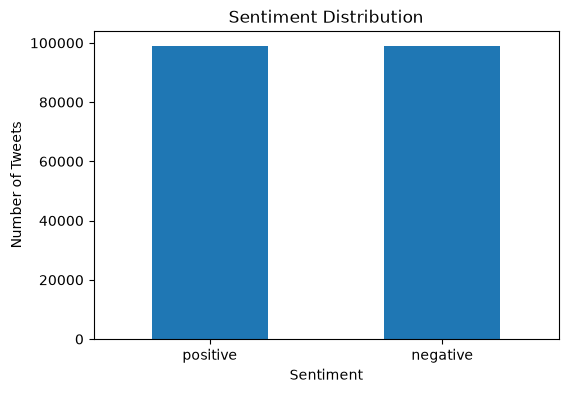

In [27]:
import matplotlib.pyplot as plt

# Sentiment distribution

sentiment_counts = sentiment_sample["sentiment_label"].value_counts()

plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)

plt.show()

Minimum text length: 1
Maximum text length: 158
Average text length: 62.44


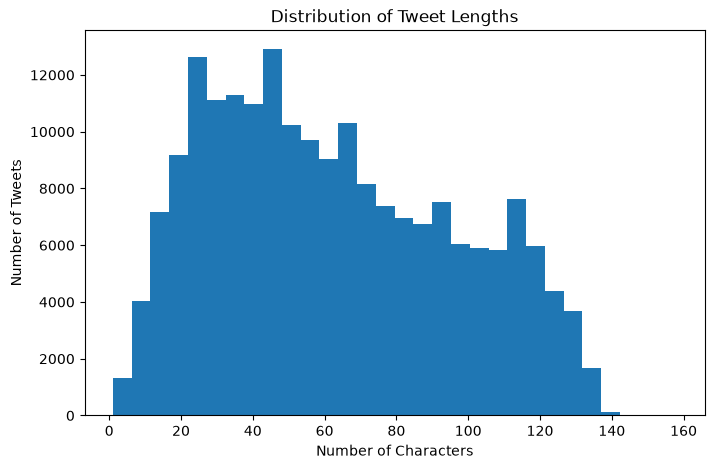

In [28]:
# Analyze tweet length

sentiment_sample["text_length"] = sentiment_sample["clean_text"].str.len()

print("Minimum text length:", sentiment_sample["text_length"].min())
print("Maximum text length:", sentiment_sample["text_length"].max())
print("Average text length:", round(sentiment_sample["text_length"].mean(), 2))

plt.figure(figsize=(8, 5))

plt.hist(sentiment_sample["text_length"], bins=30)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")

plt.show()

In [29]:
# Find the most frequent words

from collections import Counter

all_words = " ".join(sentiment_sample["clean_text"]).split()

word_counts = Counter(all_words)

print("Top 20 most frequent words:")
print(word_counts.most_common(20))

Top 20 most frequent words:
[('i', 91412), ('to', 73502), ('the', 64859), ('a', 48704), ('and', 37944), ('my', 37760), ('you', 32760), ('is', 30723), ('it', 28533), ('in', 27430), ('for', 26999), ('of', 23467), ('im', 21344), ('on', 21257), ('me', 19210), ('have', 18217), ('so', 17860), ('that', 17272), ('but', 15797), ('just', 15589)]


In [31]:
# Remove common English stopwords

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

sentiment_sample["clean_text_no_stopwords"] = sentiment_sample["clean_text"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)

print("Original:")
print(sentiment_sample["clean_text"].iloc[0])

print("\nAfter stopword removal:")
print(sentiment_sample["clean_text_no_stopwords"].iloc[0])

Original:
a thats a bummer you shoulda got david carr of third day to do it d

After stopword removal:
thats bummer shoulda got david carr day d


In [32]:
# Check most frequent words after stopword removal

all_words_no_stopwords = " ".join(
    sentiment_sample["clean_text_no_stopwords"]
).split()

word_counts_no_stopwords = Counter(all_words_no_stopwords)

print("Top 20 words after stopword removal:")
print(word_counts_no_stopwords.most_common(20))

Top 20 words after stopword removal:
[('im', 21344), ('just', 15589), ('good', 11435), ('day', 11112), ('like', 9664), ('work', 8542), ('going', 8353), ('today', 8349), ('dont', 8135), ('love', 7448), ('got', 7319), ('time', 7285), ('lol', 6313), ('really', 6144), ('know', 6069), ('u', 5920), ('night', 5736), ('want', 5173), ('think', 5109), ('thanks', 4985)]


In [33]:
# Prepare final text for machine learning

sentiment_sample["final_text"] = sentiment_sample["clean_text_no_stopwords"]

print("Final text sample:")
print(sentiment_sample["final_text"].iloc[0])

print("\nMissing final text values:")
print(sentiment_sample["final_text"].isnull().sum())

Final text sample:
thats bummer shoulda got david carr day d

Missing final text values:
0


In [34]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X = sentiment_sample["final_text"]
y = sentiment_sample["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Total samples:", len(X_train) + len(X_test))

Training samples: 158434
Testing samples: 39609
Total samples: 198043


In [35]:
# Convert text into numerical features using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

Training TF-IDF shape: (158434, 20000)
Testing TF-IDF shape: (39609, 20000)
Vocabulary size: 20000


In [36]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [37]:
# Make predictions on the test data

y_pred = model.predict(X_test_tfidf)

print("Predictions completed successfully!")
print("Number of predictions:", len(y_pred))

Predictions completed successfully!
Number of predictions: 39609


In [38]:
# Evaluate the Logistic Regression model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7652806180413543

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.74      0.76     19801
    positive       0.75      0.79      0.77     19808

    accuracy                           0.77     39609
   macro avg       0.77      0.77      0.77     39609
weighted avg       0.77      0.77      0.77     39609


Confusion Matrix:
[[14642  5159]
 [ 4138 15670]]


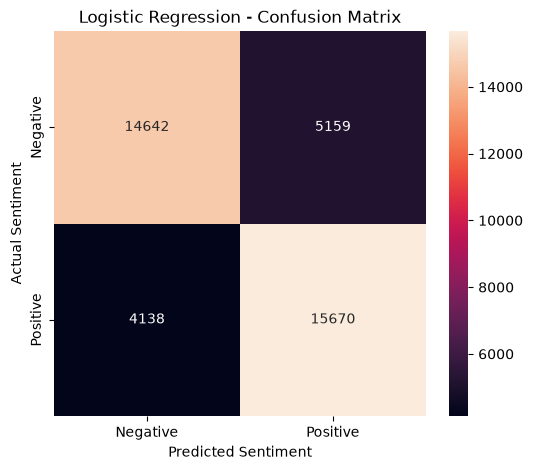

In [39]:
# Visualize the confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [40]:
# Train Multinomial Naive Bayes model

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [41]:
# Make predictions using Naive Bayes

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes predictions completed!")
print("Number of predictions:", len(y_pred_nb))

Naive Bayes predictions completed!
Number of predictions: 39609


In [42]:
# Evaluate Naive Bayes model

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7580347900729633

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.74      0.75     19801
    positive       0.75      0.77      0.76     19808

    accuracy                           0.76     39609
   macro avg       0.76      0.76      0.76     39609
weighted avg       0.76      0.76      0.76     39609


Confusion Matrix:
[[14729  5072]
 [ 4512 15296]]


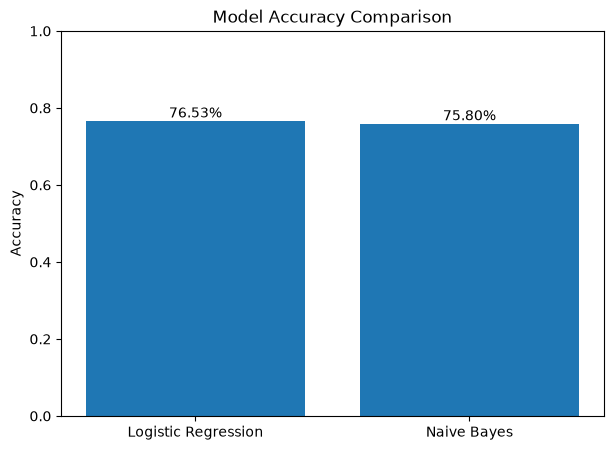

In [43]:
# Compare model accuracy

models = ["Logistic Regression", "Naive Bayes"]
accuracies = [accuracy, nb_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.01, f"{value:.2%}", ha="center")

plt.show()

In [44]:
# Train an improved Logistic Regression model

improved_model = LogisticRegression(
    C=2,
    max_iter=1000,
    random_state=42
)

improved_model.fit(X_train_tfidf, y_train)

print("Improved Logistic Regression model trained successfully!")

Improved Logistic Regression model trained successfully!


In [45]:
# Evaluate the improved Logistic Regression model

y_pred_improved = improved_model.predict(X_test_tfidf)

improved_accuracy = accuracy_score(y_test, y_pred_improved)

print("Improved Logistic Regression Accuracy:", improved_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

Improved Logistic Regression Accuracy: 0.7639425383119998

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.74      0.76     19801
    positive       0.75      0.79      0.77     19808

    accuracy                           0.76     39609
   macro avg       0.76      0.76      0.76     39609
weighted avg       0.76      0.76      0.76     39609



In [46]:
# Save the final model and TF-IDF vectorizer

import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!


In [48]:
# Create a function to predict sentiment

def predict_sentiment(text):
    cleaned_text = clean_text(text)

    text_tfidf = tfidf.transform([cleaned_text])

    prediction = model.predict(text_tfidf)[0]

    if prediction == "positive":
        return "Positive 😊"
    else:
        return "Negative 😞"
        # Test the sentiment prediction

test_text = "I absolutely love this movie! It is amazing."

result = predict_sentiment(test_text)

print("Text:", test_text)
print("Predicted Sentiment:", result)

Text: I absolutely love this movie! It is amazing.
Predicted Sentiment: Positive 😊


In [49]:
test_texts = [
    "yeah, because waiting two hours for this is exactly what I wanted",
    "not bad, could have been worse",
    "great, my phone died right when I needed it",
    "I thought it would be terrible but honestly it was pretty good",
    "can't believe they actually fixed it"
]

for text in test_texts:
    print("Text:", text)
    print("Prediction:", predict_sentiment(text))
    print("-" * 60)

Text: yeah, because waiting two hours for this is exactly what I wanted
Prediction: Negative 😞
------------------------------------------------------------
Text: not bad, could have been worse
Prediction: Negative 😞
------------------------------------------------------------
Text: great, my phone died right when I needed it
Prediction: Negative 😞
------------------------------------------------------------
Text: I thought it would be terrible but honestly it was pretty good
Prediction: Negative 😞
------------------------------------------------------------
Text: can't believe they actually fixed it
Prediction: Positive 😊
------------------------------------------------------------


In [50]:
# Test the model with realistic tweets

test_texts = [
    "I finally got the job I was waiting for",
    "The service was slow and disappointing",
    "The movie was okay, nothing special",
    "I waited forever and they cancelled my order",
    "This is exactly what I needed today",
    "I expected better from them"
]

for text in test_texts:
    prediction = predict_sentiment(text)
    print("Tweet:", text)
    print("Prediction:", prediction)
    print("-" * 60)

Tweet: I finally got the job I was waiting for
Prediction: Positive 😊
------------------------------------------------------------
Tweet: The service was slow and disappointing
Prediction: Negative 😞
------------------------------------------------------------
Tweet: The movie was okay, nothing special
Prediction: Positive 😊
------------------------------------------------------------
Tweet: I waited forever and they cancelled my order
Prediction: Negative 😞
------------------------------------------------------------
Tweet: This is exactly what I needed today
Prediction: Positive 😊
------------------------------------------------------------
Tweet: I expected better from them
Prediction: Positive 😊
------------------------------------------------------------


In [51]:
# Prediction with confidence score

def predict_sentiment_with_confidence(text):
    cleaned_text = clean_text(text)
    text_tfidf = tfidf.transform([cleaned_text])

    prediction = model.predict(text_tfidf)[0]
    probabilities = model.predict_proba(text_tfidf)[0]

    confidence = max(probabilities) * 100

    if prediction == "positive":
        sentiment = "Positive 😊"
    else:
        sentiment = "Negative 😞"

    return sentiment, confidence


# Test
text = "I really enjoyed this movie!"
sentiment, confidence = predict_sentiment_with_confidence(text)

print("Text:", text)
print("Sentiment:", sentiment)
print(f"Confidence: {confidence:.2f}%")

Text: I really enjoyed this movie!
Sentiment: Positive 😊
Confidence: 79.07%


In [52]:
import joblib

# Save the trained model and TF-IDF vectorizer
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!


In [53]:
import joblib

loaded_model = joblib.load("sentiment_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Model loaded successfully!")
print("TF-IDF vectorizer loaded successfully!")

Model loaded successfully!
TF-IDF vectorizer loaded successfully!


# Phase 3: Feature Extraction, Model Training and Evaluation

## TF-IDF Feature Extraction
TF-IDF (Term Frequency-Inverse Document Frequency) was used to convert cleaned tweets into numerical feature vectors.

- Vocabulary size: 20,000
- N-gram range: Unigrams and bigrams
- Training samples: 158,434
- Testing samples: 39,609

## Machine Learning Models
Two classification algorithms were trained and compared:

1. Logistic Regression
2. Multinomial Naive Bayes

## Model Performance

| Model | Accuracy |
|---|---:|
| Logistic Regression | 76.53% |
| Naive Bayes | 75.80% |

Logistic Regression achieved the highest accuracy and was selected as the primary model.

## Evaluation
The selected model was evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

## Prediction
A prediction function was created to classify new tweets as positive or negative.

The model was also tested with realistic and ambiguous tweets to identify limitations such as difficulty with sarcasm and subtle sentiment.

## Model Persistence
The trained model and TF-IDF vectorizer were saved using Joblib:

- `sentiment_model.pkl`
- `tfidf_vectorizer.pkl`

Both files were successfully loaded and verified.

### Phase 3 Status
**Completed — Feature extraction, model training, evaluation and prediction are complete.**

# Phase 4: Cross-Domain Testing with IMDb Reviews

The trained sentiment classification model was developed using Twitter data from the Sentiment140 dataset. To evaluate its ability to generalize to a different type of text, the model is tested on IMDb movie reviews.

The IMDb dataset contains positive and negative movie reviews. The previously trained TF-IDF vectorizer and Logistic Regression model are used without retraining.



In [ ]:
import joblib

# Load the trained Logistic Regression model
model = joblib.load("sentiment_model.pkl")

# Load the TF-IDF vectorizer used during training
vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model loaded successfully!")
print("TF-IDF vectorizer loaded successfully!")

In [1]:
import joblib

# Load the trained Logistic Regression model
model = joblib.load("sentiment_model.pkl")

# Load the TF-IDF vectorizer used during training
vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model loaded successfully!")
print("TF-IDF vectorizer loaded successfully!")

C:\Users\Abinaya RS\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Abinaya RS\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.9.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded successfully!
TF-IDF vectorizer loaded successfully!


C:\Users\Abinaya RS\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.9.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
import os
import pandas as pd

# IMDb dataset paths
imdb_train_path = "../data/aclImdb/train"
imdb_test_path = "../data/aclImdb/test"

# Check that the folders exist
print("IMDb train folder exists:", os.path.exists(imdb_train_path))
print("IMDb test folder exists:", os.path.exists(imdb_test_path))

IMDb train folder exists: True
IMDb test folder exists: True


In [3]:
import os
import glob
import pandas as pd

# Paths to IMDb test reviews
pos_path = "../data/aclImdb/test/pos"
neg_path = "../data/aclImdb/test/neg"

# Get review file paths
pos_files = glob.glob(os.path.join(pos_path, "*.txt"))
neg_files = glob.glob(os.path.join(neg_path, "*.txt"))

print("Positive reviews available:", len(pos_files))
print("Negative reviews available:", len(neg_files))

# Use 5,000 reviews from each class
pos_files = pos_files[:5000]
neg_files = neg_files[:5000]

# Read reviews
reviews = []
labels = []

for file in pos_files:
    with open(file, "r", encoding="utf-8") as f:
        reviews.append(f.read())
        labels.append(1)

for file in neg_files:
    with open(file, "r", encoding="utf-8") as f:
        reviews.append(f.read())
        labels.append(0)

imdb_df = pd.DataFrame({
    "review": reviews,
    "sentiment": labels
})

print("\nIMDb reviews loaded:", len(imdb_df))
print(imdb_df["sentiment"].value_counts())

Positive reviews available: 12500
Negative reviews available: 12500

IMDb reviews loaded: 10000
sentiment
1    5000
0    5000
Name: count, dtype: int64


In [5]:
import re

In [6]:
# IMDb text preprocessing
def clean_imdb_text(text):
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
imdb_df["clean_review"] = imdb_df["review"].apply(clean_imdb_text)

print("IMDb preprocessing completed!")
print("\nOriginal review:")
print(imdb_df["review"].iloc[0][:300])

print("\nCleaned review:")
print(imdb_df["clean_review"].iloc[0][:300])

IMDb preprocessing completed!

Original review:
I went and saw this movie last night after being coaxed to by a few friends of mine. I'll admit that I was reluctant to see it because from what I knew of Ashton Kutcher he was only able to do comedy. I was wrong. Kutcher played the character of Jake Fischer very well, and Kevin Costner played Ben R

Cleaned review:
i went and saw this movie last night after being coaxed to by a few friends of mine i ll admit that i was reluctant to see it because from what i knew of ashton kutcher he was only able to do comedy i was wrong kutcher played the character of jake fischer very well and kevin costner played ben randa


In [7]:
# Convert cleaned IMDb reviews into TF-IDF features
X_imdb = vectorizer.transform(imdb_df["clean_review"])

print("IMDb reviews converted into TF-IDF features.")
print("Feature matrix shape:", X_imdb.shape)

IMDb reviews converted into TF-IDF features.
Feature matrix shape: (10000, 20000)


In [8]:
# Predict sentiment for IMDb reviews
imdb_predictions = model.predict(X_imdb)

# Add predictions to the dataframe
imdb_df["predicted_sentiment"] = imdb_predictions

print("IMDb sentiment predictions completed!")
print("\nPrediction distribution:")
print(imdb_df["predicted_sentiment"].value_counts())

IMDb sentiment predictions completed!

Prediction distribution:
predicted_sentiment
positive    6418
negative    3582
Name: count, dtype: int64


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
imdb_accuracy = accuracy_score(
    imdb_df["sentiment"],
    imdb_df["predicted_sentiment"]
)

print(f"IMDb Cross-Domain Accuracy: {imdb_accuracy:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        imdb_df["sentiment"],
        imdb_df["predicted_sentiment"],
        target_names=["Negative", "Positive"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        imdb_df["sentiment"],
        imdb_df["predicted_sentiment"]
    )
)

TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=[0 1] and y_pred=['negative' 'positive']. Make sure that the predictions provided by the classifier coincides with the true labels.

In [10]:
# Convert model predictions to numeric labels for evaluation
if imdb_df["predicted_sentiment"].dtype == "object":
    prediction_mapping = {
        "negative": 0,
        "positive": 1
    }

    imdb_df["predicted_numeric"] = (
        imdb_df["predicted_sentiment"]
        .map(prediction_mapping)
    )
else:
    imdb_df["predicted_numeric"] = imdb_df["predicted_sentiment"]

# Calculate IMDb accuracy
imdb_accuracy = accuracy_score(
    imdb_df["sentiment"],
    imdb_df["predicted_numeric"]
)

print(f"IMDb Cross-Domain Accuracy: {imdb_accuracy:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        imdb_df["sentiment"],
        imdb_df["predicted_numeric"],
        target_names=["Negative", "Positive"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        imdb_df["sentiment"],
        imdb_df["predicted_numeric"]
    )
)

IMDb Cross-Domain Accuracy: 70.84%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.57      0.66      5000
    Positive       0.66      0.85      0.74      5000

    accuracy                           0.71     10000
   macro avg       0.73      0.71      0.70     10000
weighted avg       0.73      0.71      0.70     10000


Confusion Matrix:
[[2833 2167]
 [ 749 4251]]


# Phase 5: Practical Sentiment Prediction

The trained Logistic Regression model was tested on new, unseen text samples to demonstrate its practical prediction capability.

The model predicts whether a given text expresses positive or negative sentiment. Additional ambiguous examples are used to observe limitations in handling sarcasm and subtle sentiment.

In [11]:
def predict_sentiment(text):
    # Clean the input text
    cleaned_text = clean_imdb_text(text)

    # Convert text into TF-IDF features
    text_vector = vectorizer.transform([cleaned_text])

    # Predict sentiment
    prediction = model.predict(text_vector)[0]

    # Convert model output to readable label
    if prediction == 1 or prediction == "positive":
        return "Positive"
    else:
        return "Negative"


print("Prediction function created successfully!")

Prediction function created successfully!


In [12]:
test_sentences = [
    "I absolutely loved this movie, it was fantastic!",
    "The movie was boring and a complete waste of time.",
    "The acting was good and I really enjoyed the story.",
    "I expected much more from this movie.",
    "The movie was okay, but nothing special."
]

for sentence in test_sentences:
    print(f"Text: {sentence}")
    print(f"Prediction: {predict_sentiment(sentence)}")
    print("-" * 70)
    

Text: I absolutely loved this movie, it was fantastic!
Prediction: Positive
----------------------------------------------------------------------
Text: The movie was boring and a complete waste of time.
Prediction: Negative
----------------------------------------------------------------------
Text: The acting was good and I really enjoyed the story.
Prediction: Positive
----------------------------------------------------------------------
Text: I expected much more from this movie.
Prediction: Positive
----------------------------------------------------------------------
Text: The movie was okay, but nothing special.
Prediction: Positive
----------------------------------------------------------------------


In [13]:
ambiguous_sentences = [
    "Oh great, another three hours of my life I'll never get back.",
    "The movie was not bad, but I wouldn't watch it again.",
    "The story had some good moments, but the ending was disappointing.",
    "Wow, what an amazing way to ruin a perfectly good story!"
]

for sentence in ambiguous_sentences:
    print(f"Text: {sentence}")
    print(f"Prediction: {predict_sentiment(sentence)}")
    print("-" * 70)

Text: Oh great, another three hours of my life I'll never get back.
Prediction: Positive
----------------------------------------------------------------------
Text: The movie was not bad, but I wouldn't watch it again.
Prediction: Negative
----------------------------------------------------------------------
Text: The story had some good moments, but the ending was disappointing.
Prediction: Negative
----------------------------------------------------------------------
Text: Wow, what an amazing way to ruin a perfectly good story!
Prediction: Positive
----------------------------------------------------------------------


# Phase 5: Practical Prediction Results and Limitations

The trained Logistic Regression model was successfully used to classify new, unseen text as positive or negative.

The practical tests demonstrated that the model can identify clear positive and negative sentiment. However, predictions on ambiguous, mixed, or sarcastic statements may be less reliable because the TF-IDF and Logistic Regression approach relies mainly on learned word and phrase patterns rather than deeper contextual understanding.

## Key Limitations

- Difficulty understanding sarcasm and irony.
- Reduced reliability for mixed or subtle sentiment.
- Performance can vary when the input text differs significantly from the training domain.
- The model is limited to positive and negative sentiment classification.

# Phase 6: Final Results and Project Summary

## Model Performance

The project evaluated two machine learning algorithms on the Sentiment140 Twitter dataset:

| Model | Accuracy |
|---|---:|
| Logistic Regression | 76.53% |
| Multinomial Naive Bayes | 75.80% |

Logistic Regression achieved the higher accuracy on the Twitter test set and was used as the primary model for further testing.

## Cross-Domain Evaluation

The trained Logistic Regression model was additionally evaluated on 10,000 IMDb movie reviews:

- Positive reviews: 5,000
- Negative reviews: 5,000
- IMDb cross-domain accuracy: **70.84%**

### IMDb Classification Performance

| Sentiment | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Negative | 0.79 | 0.57 | 0.66 |
| Positive | 0.66 | 0.85 | 0.74 |

## Project Conclusion

The project demonstrates an end-to-end sentiment analysis workflow using Python and machine learning. Text data was cleaned and transformed using TF-IDF, followed by classification using Logistic Regression and Multinomial Naive Bayes. The selected model was evaluated on both Twitter data and a separate IMDb dataset to examine cross-domain generalization.

The practical prediction tests also demonstrated the model's ability to classify new text while highlighting limitations in handling sarcasm, mixed sentiment and subtle contextual meaning.

# Project Overview

### Objective
To develop a machine learning-based sentiment analysis system capable of classifying text as positive or negative.

### Dataset
- Sentiment140 Twitter dataset
- IMDb movie review dataset for cross-domain evaluation

### Technologies
- Python
- Pandas
- NumPy
- NLTK
- Scikit-learn
- TF-IDF
- Matplotlib
- Seaborn
- Jupyter Notebook
- Joblib

### Machine Learning Models
- Logistic Regression
- Multinomial Naive Bayes

### Key Steps
1. Data loading and exploration
2. Text preprocessing and cleaning
3. Feature extraction using TF-IDF
4. Model training
5. Model evaluation
6. Cross-domain testing
7. Practical sentiment prediction
8. Model persistence

# Final Project Status

### Completed Components

- [x] Sentiment140 dataset loading and exploration
- [x] Text preprocessing and cleaning
- [x] Stopword removal
- [x] TF-IDF feature extraction
- [x] Logistic Regression model
- [x] Multinomial Naive Bayes model
- [x] Model comparison
- [x] Accuracy, precision, recall and F1-score evaluation
- [x] Confusion matrix analysis
- [x] New-text sentiment prediction
- [x] IMDb cross-domain evaluation
- [x] Practical prediction testing
- [x] Model and TF-IDF vectorizer persistence
- [x] Project results and limitations documented

### Final Results

- Twitter Logistic Regression accuracy: **76.53%**
- Twitter Multinomial Naive Bayes accuracy: **75.80%**
- IMDb cross-domain accuracy: **70.84%**
- IMDb reviews evaluated: **10,000**